In [30]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("../../data/raw/municipal_training_set_1100.csv")

print(df.head())
print(df.columns.tolist())

    report_id resident_id     resident_name                resident_email  \
0  RPT-354769    RES-1028    Jack Hernandez  jack.hernandez28@example.com   
1  RPT-928980    RES-6964               NaN                           NaN   
2  RPT-337675    RES-2013  William Gonzalez  william.gonzalez@example.com   
3  RPT-528487    RES-5089    Patricia Davis    patricia.davis104@mail.com   
4  RPT-609991    RES-1044    Susan Williams  susan.williams26@example.com   

    resident_phone     issue_type  \
0  +1-758-555-1049          noise   
1              NaN        pothole   
2  +1-362-555-3105          noise   
3  +1-380-555-5810  water_leakage   
4  +1-281-555-1496        pothole   

                                   issue_description issue_status  \
0  Unauthorized late-night party with amplified s...     resolved   
1  Deep pothole near the bus stop making it dange...  in-progress   
2  Construction crew is starting their work at 5 ...  in-progress   
3  URGENT: A significant water leak ne

In [27]:
print(df.columns.tolist())


['report_id', 'resident_id', 'resident_name', 'resident_email', 'resident_phone', 'issue_type', 'issue_description', 'issue_status', 'report_datetime', 'location_street_address', 'location_city', 'location_state', 'location_postal_code', 'location_country', 'latitude', 'longitude', 'photo_url', 'municipal_department', 'resolution_datetime', 'resolution_notes', 'is_anonymous', 'priority_level', 'priority_score', 'severity_score', 'area_importance', 'citizen_reports_count']


In [29]:

print(type(y_val))
print(type(y_pred))

print(y_val[:5])
print(y_pred[:5])


<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
328         Water Department
688         Water Department
413    Electrical Department
788       Drainage Authority
244         Water Department
Name: municipal_department, dtype: object
['water_leakage' 'water_leakage' 'streetlight' 'drainage' 'water_leakage']


In [31]:
X = df["issue_description"]
y = df["issue_type"]

In [32]:
X_vec = vectorizer.transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42
)

y_pred = model.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9954545454545455
                 precision    recall  f1-score   support

       drainage       1.00      1.00      1.00        29
        garbage       1.00      1.00      1.00        31
       graffiti       1.00      1.00      1.00         4
illegal-dumping       1.00      1.00      1.00         3
illegal_parking       1.00      1.00      1.00        29
          noise       1.00      1.00      1.00        22
          other       0.88      1.00      0.93         7
        pothole       1.00      0.97      0.98        33
    streetlight       1.00      1.00      1.00        26
     water-leak       1.00      1.00      1.00         8
  water_leakage       1.00      1.00      1.00        28

       accuracy                           1.00       220
      macro avg       0.99      1.00      0.99       220
   weighted avg       1.00      1.00      1.00       220



In [33]:
print(y_val.head())
print(y_pred[:5])

328    water_leakage
688    water_leakage
413      streetlight
788         drainage
244    water_leakage
Name: issue_type, dtype: object
['water_leakage' 'water_leakage' 'streetlight' 'drainage' 'water_leakage']


In [34]:
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9954545454545455
                 precision    recall  f1-score   support

       drainage       1.00      1.00      1.00        29
        garbage       1.00      1.00      1.00        31
       graffiti       1.00      1.00      1.00         4
illegal-dumping       1.00      1.00      1.00         3
illegal_parking       1.00      1.00      1.00        29
          noise       1.00      1.00      1.00        22
          other       0.88      1.00      0.93         7
        pothole       1.00      0.97      0.98        33
    streetlight       1.00      1.00      1.00        26
     water-leak       1.00      1.00      1.00         8
  water_leakage       1.00      1.00      1.00        28

       accuracy                           1.00       220
      macro avg       0.99      1.00      0.99       220
   weighted avg       1.00      1.00      1.00       220



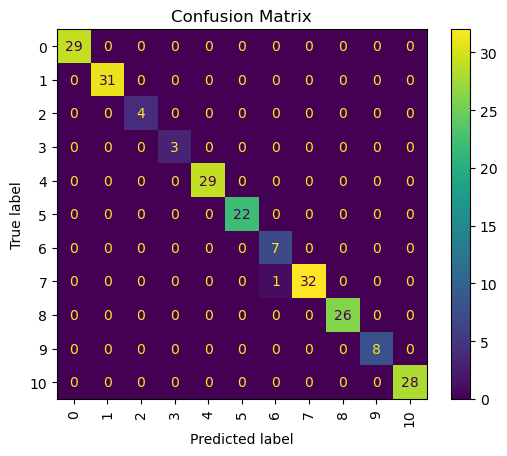

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)

plt.title("Confusion Matrix")
plt.show()

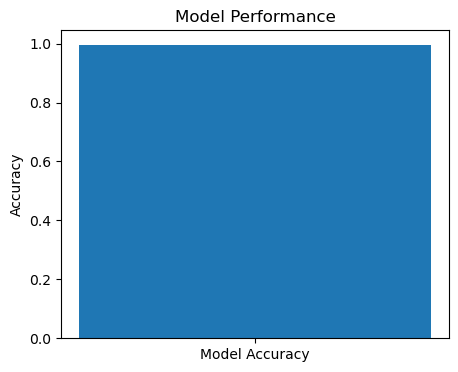

In [36]:
accuracy = accuracy_score(y_val, y_pred)

plt.figure(figsize=(5,4))
plt.bar(["Model Accuracy"], [accuracy])
plt.ylabel("Accuracy")
plt.title("Model Performance")
plt.show()